In [ ]:
#Adding stochasticity
#NK cell killing rate most sensitive parameter
#Add noise proportional to NK killing rate to the 



In [103]:
import sdeint
from sdeint import itoint
from sdeint import itoEuler
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import itertools
import time

In [193]:
KPB25L_no_ICI_no_mut_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0095, 'K_C': 0.4, 
                               'd_D': 1.0, 'sigma_N': 0.0005, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 
                               'lambda_Tr_comb': 0.00025, 'd_T8': 0.01, 'lambda_T8_comb': 3e-06, 'K_Tr': 0.01, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 
                               'NK_noise':0.5,'T8_noise':0.3,'D_noise':0.3,
                               'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}

In [194]:
df = pd.read_csv("Mammary_data_response_1e8.csv")
df_KPB25L = df[df['Cell_Line'] == 'KPB25L']
df_KPB25L_no_ICI = df_KPB25L[df_KPB25L['Mouse_treatment']=='no_treatment']
df_KPB25L_no_ICI_no_mut = df_KPB25L_no_ICI[df_KPB25L_no_ICI['Condition'].str.startswith("day")]
df_KPB25L_no_ICI_no_mut

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
49,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,Baseline,GSM3554692,KPB25L,"Mammary cancer, NOS",GSE124821
50,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,Baseline,GSM3554693,KPB25L,"Mammary cancer, NOS",GSE124821
51,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,Baseline,GSM3554694,KPB25L,"Mammary cancer, NOS",GSE124821
52,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,Baseline,GSM3554695,KPB25L,"Mammary cancer, NOS",GSE124821
57,SRX5100596,0.003232,0.001002,0.000000,0.000360,no_treatment,day3,day3,Baseline,GSM3554700,KPB25L,"Mammary cancer, NOS",GSE124821
59,SRX5100598,0.002572,0.000723,0.000000,0.000329,no_treatment,day3,day3,Baseline,GSM3554702,KPB25L,"Mammary cancer, NOS",GSE124821
60,SRX5100618,0.002565,0.000501,0.000000,0.000285,no_treatment,day3,day3,Baseline,GSM3554703,KPB25L,"Mammary cancer, NOS",GSE124821
61,SRX5100617,0.002757,0.000712,0.000000,0.000344,no_treatment,day3,day3,Baseline,GSM3554704,KPB25L,"Mammary cancer, NOS",GSE124821
62,SRX5100591,0.004276,0.000643,0.000000,0.000653,no_treatment,day3,day3,Baseline,GSM3554705,KPB25L,"Mammary cancer, NOS",GSE124821


In [195]:
# the scatter data for the KPB25L ICI data 
#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []
quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]
time_points = ["day3","day7"]

for day in time_points:
    day_df = df_KPB25L_no_ICI_no_mut[df_KPB25L_no_ICI_no_mut['Condition'].str.contains(day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    stds = day_df.filter(items=quanTIseq_cols).std()
    print("Averages:")
    print(averages)
    

    # print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    
    print(mutagen_total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)


Number of replicates 5
Averages:
Dendritic_quanTIseq    0.003080
NK_quanTIseq           0.000716
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.000394
dtype: float64
0.004190843024

Number of replicates 4
Averages:
Dendritic_quanTIseq    0.003067
NK_quanTIseq           0.001023
T.CD8_quanTIseq        0.000017
Tregs_quanTIseq        0.000367
dtype: float64
0.004473146355


In [196]:
def cancer_deterministic(y,t,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))


In [197]:
params = KPB25L_no_ICI_no_mut_params.copy()
tspan = (0.0,100.0,)
C0 = [params['C_init'],params['D_init'],params['N_init'],params['Tr_init'],params['T8_init']]

In [198]:
p = params.copy()
def run_sim(n_runs,p,tspan,save_every = 10,step = 0.01):
    outputs = np.zeros((n_runs,int(np.ceil(len(np.arange(tspan[0],tspan[1],step))/save_every)),5))
    t = np.arange(tspan[0],tspan[1],step)
    t_sliced = t[::save_every]
    for i in range(n_runs):
        def cancer_deterministic_parametrised(y, t):
            
            return cancer_deterministic(y,t, 
                p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
                p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
                p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
                p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
                p['K_D'], p['K_Tr']
            )
        def cancer_stochastic_parametrised(y,t):
            C,D,N,Tr,T8 = y
            output = np.diag([p['NK_noise']*p['eta_N']*N*C+p['T8_noise']*p['eta_8']*T8*C,p['D_noise']*p['lambda_DC_comb']*C/(C+p['K_C']),p['NK_noise']*p['sigma_N'],0.0,p['T8_noise']*p['lambda_T8_comb']*D/(p['K_D']+D)/(1+Tr/p['K_Tr'])])
            return output
        
        
        sol = itoEuler(cancer_deterministic_parametrised, cancer_stochastic_parametrised, C0, t)
        save_sol = sol[::save_every,:]
        outputs[i] = save_sol
    return t_sliced,outputs

In [199]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plotting Setup ---
n_sims = 1000
# scale = 1500 # Adjust for more/less noise

# Run the ensemble
t_eval,sim_data = run_sim(n_sims,p,tspan)
mean_sim = np.mean(sim_data, axis=0)

# Colors
c1 = (216/255, 27/255, 96/255) # Pinkish (Stochastic Mean)
c3 = (255/255, 193/255, 7/255) # Yellow (Data points)




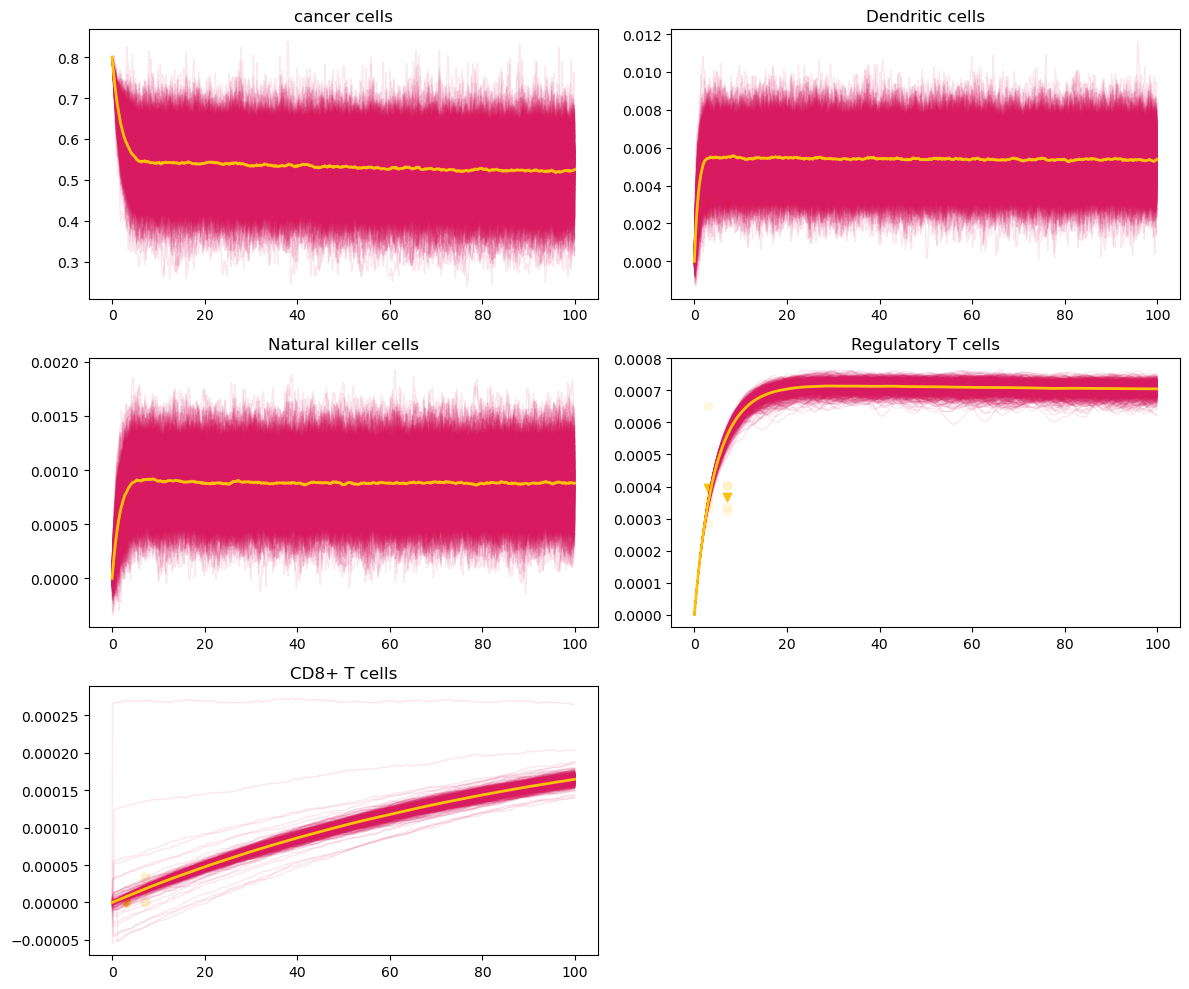

In [200]:
c1 = (216/255, 27/255, 96/255) # Pinkish (Stochastic Mean)
c3 = (255/255, 193/255, 7/255) # Yellow (Data points)
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

titles = ['cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
indices = [(0,0), (0,1), (1,0), (1,1), (2,0)]
# Data mapping (using the variable names from your snippet)
scatter_data = [None, scatter_mutagen_Ds, scatter_mutagen_NKs, scatter_mutagen_Tregs, scatter_mutagen_T8s]
v_markers = [None, mutagen_Ds, mutagen_NKs, mutagen_Tregs, mutagen_T8s]

# scatter_data = [None,None,None,None,None]
# v_markers = [None,None,None,None,None]

for i, (r, c) in enumerate(indices):
    axis = ax[r, c]
    
    # 1. Plot individual stochastic runs (Light/Transparent)
    for s in range(n_sims):
        axis.plot(t_eval, sim_data[s, :, i], color=c1, alpha=0.1, linewidth=1)
    
    # 2. Plot the Mean of the stochastic runs (Bold)
    axis.plot(t_eval, mean_sim[:, i], color=c3, linewidth=2, label='Stochastic Mean')
    
    # 3. Plot your scatter points (The light yellow background points)
    if scatter_data[i] is not None:
        axis.scatter(scatter_mutagen_times, scatter_data[i], alpha=0.1, color=c3)
    
    # 4. Plot the "v" markers (The specific data points at t=3, 7)
    if v_markers[i] is not None:
        axis.scatter([3.0, 7.0], v_markers[i][:2], alpha=1.0, marker='v', color=c3)

    axis.set_title(titles[i])

ax[2, 1].set_visible(False)
plt.tight_layout()
plt.show()


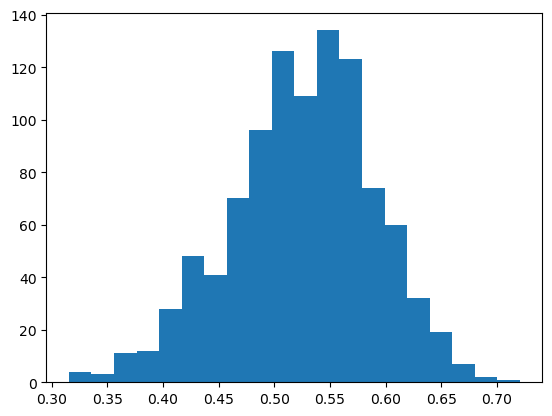

In [201]:
end_point = sim_data[:,-1,0]
plt.hist(end_point,bins = 20)
plt.show()

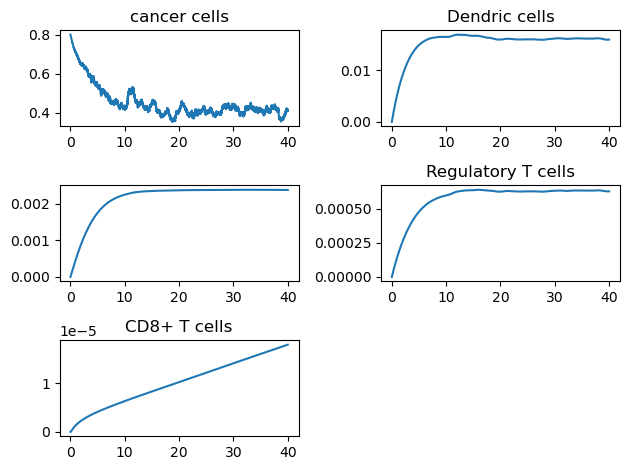

In [49]:
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
import inspect



sig = inspect.signature(itoEuler)

# Print everything
for name, param in sig.parameters.items():
    print(f"Name: {name}")
    print(f"  Default: {param.default}")
    print(f"  Kind: {param.kind}")
    print(f"  Annotation: {param.annotation}")
    print("-" * 10)

Name: f
  Default: <class 'inspect._empty'>
  Kind: POSITIONAL_OR_KEYWORD
  Annotation: <class 'inspect._empty'>
----------
Name: G
  Default: <class 'inspect._empty'>
  Kind: POSITIONAL_OR_KEYWORD
  Annotation: <class 'inspect._empty'>
----------
Name: y0
  Default: <class 'inspect._empty'>
  Kind: POSITIONAL_OR_KEYWORD
  Annotation: <class 'inspect._empty'>
----------
Name: tspan
  Default: <class 'inspect._empty'>
  Kind: POSITIONAL_OR_KEYWORD
  Annotation: <class 'inspect._empty'>
----------
Name: dW
  Default: None
  Kind: POSITIONAL_OR_KEYWORD
  Annotation: <class 'inspect._empty'>
----------
Name: generator
  Default: None
  Kind: POSITIONAL_OR_KEYWORD
  Annotation: <class 'inspect._empty'>
----------
